Exploratory data analysis (EDA) is a crucial component of data science which allows you to understand the basics of what your data looks like and what kinds of questions might be answered. For this task, we are going to clean, sanitise and explore our data. Using the automobile dataset, complete the steps outlined in this notebook by writing code in the cells.

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import seaborn as sns

from datetime import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
# Load the movies dataset
automobiles_df = pd.read_csv('automobile.txt')

In [3]:
automobiles_df.head(2).T

,0,1
symboling,3,3
normalized-losses,?,?
make,alfa-romero,alfa-romero
fuel-type,gas,gas
aspiration,std,std
num-of-doors,two,two
body-style,convertible,convertible
drive-wheels,rwd,rwd
engine-location,front,front
wheel-base,88.6,88.6


In [4]:
automobiles_df.shape

(205, 26)

### Data Cleansing
#### Clean the data

Identify columns that are redundant or unnecessary. It is always easier to make your decisions based on data which is relevant and concise. Remove the following columns `['normalized-losses', 'symboling']` from the data set as they will not be used in the analysis.

In [5]:
# Code here
automobiles_df.drop('normalized-losses', axis=1, inplace=True)
automobiles_df.drop('symboling', axis=1, inplace=True)


In [6]:
automobiles_df.shape

(205, 24)

In [7]:
automobiles_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               205 non-null    str    
 1   fuel-type          205 non-null    str    
 2   aspiration         205 non-null    str    
 3   num-of-doors       205 non-null    str    
 4   body-style         205 non-null    str    
 5   drive-wheels       205 non-null    str    
 6   engine-location    205 non-null    str    
 7   wheel-base         205 non-null    float64
 8   length             205 non-null    float64
 9   width              205 non-null    float64
 10  height             205 non-null    float64
 11  curb-weight        205 non-null    int64  
 12  engine-type        205 non-null    str    
 13  num-of-cylinders   205 non-null    str    
 14  engine-size        205 non-null    int64  
 15  fuel-system        205 non-null    str    
 16  bore               205 non-null    st

#### Remove any duplicate rows

In [8]:
automobiles_df.shape

(205, 24)

In [9]:
automobiles_df.duplicated().sum()

np.int64(0)

In [10]:
# Code here
automobiles_df.drop_duplicates(inplace=True)

In [11]:
automobiles_df.shape

(205, 24)

#### Remove rows with missing data

Some automobiles in the database have missing values which implies that their values have not been recorded or some information is missing. Discard such entries from the dataframe.

In [12]:
# Code here
automobiles_df.isnull().sum()

make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [13]:
automobiles_df.replace("?", np.nan, inplace=True)
automobiles_df = automobiles_df.dropna()

In [14]:
automobiles_df.isnull().sum()

make                 0
fuel-type            0
aspiration           0
num-of-doors         0
body-style           0
drive-wheels         0
engine-location      0
wheel-base           0
length               0
width                0
height               0
curb-weight          0
engine-type          0
num-of-cylinders     0
engine-size          0
fuel-system          0
bore                 0
stroke               0
compression-ratio    0
horsepower           0
peak-rpm             0
city-mpg             0
highway-mpg          0
price                0
dtype: int64

In [15]:
automobiles_df.shape

(193, 24)

Change columns with numerical data column to an integer data type using numpy’s `int64` method.

In [16]:
# Code here
automobiles_df.info()

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    str    
 1   fuel-type          193 non-null    str    
 2   aspiration         193 non-null    str    
 3   num-of-doors       193 non-null    str    
 4   body-style         193 non-null    str    
 5   drive-wheels       193 non-null    str    
 6   engine-location    193 non-null    str    
 7   wheel-base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb-weight        193 non-null    int64  
 12  engine-type        193 non-null    str    
 13  num-of-cylinders   193 non-null    str    
 14  engine-size        193 non-null    int64  
 15  fuel-system        193 non-null    str    
 16  bore               193 non-null    str    

In [17]:
automobiles_df["price"] = pd.to_numeric(automobiles_df["price"])
automobiles_df["horsepower"] = pd.to_numeric(automobiles_df["horsepower"])
automobiles_df["peak-rpm"] = pd.to_numeric(automobiles_df["peak-rpm"])
automobiles_df["bore"] = pd.to_numeric(automobiles_df["bore"])
automobiles_df["stroke"] = pd.to_numeric(automobiles_df["stroke"])
automobiles_df["price"] = pd.to_numeric(automobiles_df["price"])

In [18]:
automobiles_df.info()

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    str    
 1   fuel-type          193 non-null    str    
 2   aspiration         193 non-null    str    
 3   num-of-doors       193 non-null    str    
 4   body-style         193 non-null    str    
 5   drive-wheels       193 non-null    str    
 6   engine-location    193 non-null    str    
 7   wheel-base         193 non-null    float64
 8   length             193 non-null    float64
 9   width              193 non-null    float64
 10  height             193 non-null    float64
 11  curb-weight        193 non-null    int64  
 12  engine-type        193 non-null    str    
 13  num-of-cylinders   193 non-null    str    
 14  engine-size        193 non-null    int64  
 15  fuel-system        193 non-null    str    
 16  bore               193 non-null    float64

In [19]:
automobiles_df[['wheel-base','length','width','height','curb-weight','engine-size','compression-ratio','city-mpg', 'highway-mpg']]= automobiles_df[['wheel-base','length','width','height','curb-weight','engine-size','compression-ratio','city-mpg', 'highway-mpg']].astype(np.int64)

In [20]:
automobiles_df.info()

<class 'pandas.DataFrame'>
Index: 193 entries, 0 to 204
Data columns (total 24 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   make               193 non-null    str    
 1   fuel-type          193 non-null    str    
 2   aspiration         193 non-null    str    
 3   num-of-doors       193 non-null    str    
 4   body-style         193 non-null    str    
 5   drive-wheels       193 non-null    str    
 6   engine-location    193 non-null    str    
 7   wheel-base         193 non-null    int64  
 8   length             193 non-null    int64  
 9   width              193 non-null    int64  
 10  height             193 non-null    int64  
 11  curb-weight        193 non-null    int64  
 12  engine-type        193 non-null    str    
 13  num-of-cylinders   193 non-null    str    
 14  engine-size        193 non-null    int64  
 15  fuel-system        193 non-null    str    
 16  bore               193 non-null    float64

In [21]:
automobiles_df.head(2).T

,0,1
make,alfa-romero,alfa-romero
fuel-type,gas,gas
aspiration,std,std
num-of-doors,two,two
body-style,convertible,convertible
drive-wheels,rwd,rwd
engine-location,front,front
wheel-base,88,88
length,168,168
width,64,64


### Finding Certain Categories
Locate all automobiles in the "hatchback" genre.

In [22]:
# Create a dataframe with all the cars in the "hatchback' category
hatchback_cars =automobiles_df[automobiles_df['body-style'] == "hatchback"]

In [23]:
hatchback_cars

,make,fuel-type,aspiration,num-of-doors,body-style,drive-wheels,engine-location,wheel-base,length,width,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
2,alfa-romero,gas,std,two,hatchback,rwd,front,94,171,65,...,152,mpfi,2.68,3.47,9,154,5000,19,26,16500
18,chevrolet,gas,std,two,hatchback,fwd,front,88,141,60,...,61,2bbl,2.91,3.03,9,48,5100,47,53,5151
19,chevrolet,gas,std,two,hatchback,fwd,front,94,155,63,...,90,2bbl,3.03,3.11,9,70,5400,38,43,6295
21,dodge,gas,std,two,hatchback,fwd,front,93,157,63,...,90,2bbl,2.97,3.23,9,68,5500,37,41,5572
22,dodge,gas,std,two,hatchback,fwd,front,93,157,63,...,90,2bbl,2.97,3.23,9,68,5500,31,38,6377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
175,toyota,gas,std,four,hatchback,fwd,front,102,175,66,...,122,mpfi,3.31,3.54,8,92,4200,27,32,9988
177,toyota,gas,std,four,hatchback,fwd,front,102,175,66,...,122,mpfi,3.31,3.54,8,92,4200,27,32,11248
178,toyota,gas,std,two,hatchback,rwd,front,102,183,67,...,171,mpfi,3.27,3.35,9,161,5200,20,24,16558
179,toyota,gas,std,two,hatchback,rwd,front,102,183,67,...,171,mpfi,3.27,3.35,9,161,5200,19,24,15998


### Now onto the exploration

#### Identify relationships between variables (features)

The main goal here is to identify and create relationships that can help you formulate ideas. We have defined questions to help you identify some relationships to explore.

#### Which are the 5 most expensive cars?

How do the most expensive and cheapest cars compare? Exploring the most expensive cars highlights if some moviecars are worth the money spent on them based on their fuel economy (mpg or miles per gallon)

# The five most expensive automobiles were identified and compared with the five least expensive vehicles based on fuel echonomy measurements. The analysis indicated that high prices cars generally offred lower fuel  efficiency due to larger engines and performance-oriented designs. whereas cheaper cars tended to provide better mileage and economical operation.

In [24]:
# Code here

In [25]:
automobiles_df['price']  = automobiles_df['price'].replace('?', np.nan)
automobiles_df  = automobiles_df.dropna(subset=['price'])


In [26]:
automobiles_df['price']  =automobiles_df['price'].astype(np.int64)

In [27]:

top_five_expensive = automobiles_df.sort_values(by='price', ascending=False).head(5)
print(top_five_expensive[['make','price','wheel-base','length','width','height','curb-weight','engine-size','compression-ratio','city-mpg', 'highway-mpg']])

              make  price  wheel-base  length  width  height  curb-weight  \
74   mercedes-benz  45400         112     199     72      55         3715   
16             bmw  41315         103     193     67      53         3380   
73   mercedes-benz  40960         120     208     71      56         3900   
128        porsche  37028          89     168     65      51         2800   
17             bmw  36880         110     197     70      56         3505   

     engine-size  compression-ratio  city-mpg  highway-mpg  
74           304                  8        14           16  
16           209                  8        16           22  
73           308                  8        14           16  
128          194                  9        17           25  
17           209                  8        15           20  


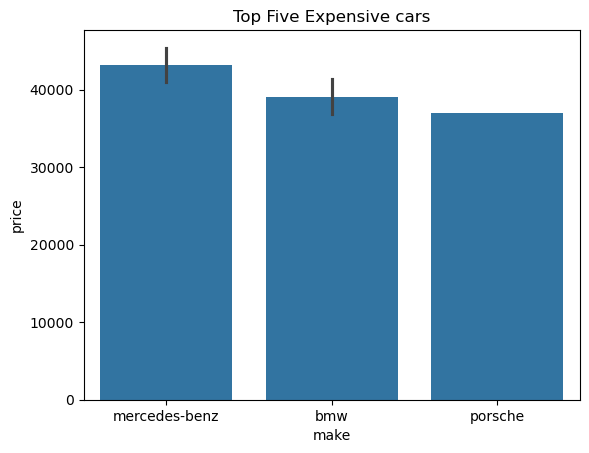

In [28]:
sns.barplot(data=top_five_expensive, x='make', y='price')
plt.title('Top Five Expensive cars')
plt.show()

In [29]:
top_five_cheapest = automobiles_df.sort_values(by='price', ascending=True).head(5)
print(top_five_cheapest[['make','price','wheel-base','length','width','height','curb-weight','engine-size','compression-ratio','city-mpg', 'highway-mpg']])

           make  price  wheel-base  length  width  height  curb-weight  \
138      subaru   5118          93     156     63      53         2050   
18    chevrolet   5151          88     141     60      53         1488   
50        mazda   5195          93     159     64      54         1890   
150      toyota   5348          95     158     63      54         1985   
76   mitsubishi   5389          93     157     64      50         1918   

     engine-size  compression-ratio  city-mpg  highway-mpg  
138           97                  9        31           36  
18            61                  9        47           53  
50            91                  9        30           31  
150           92                  9        35           39  
76            92                  9        37           41  


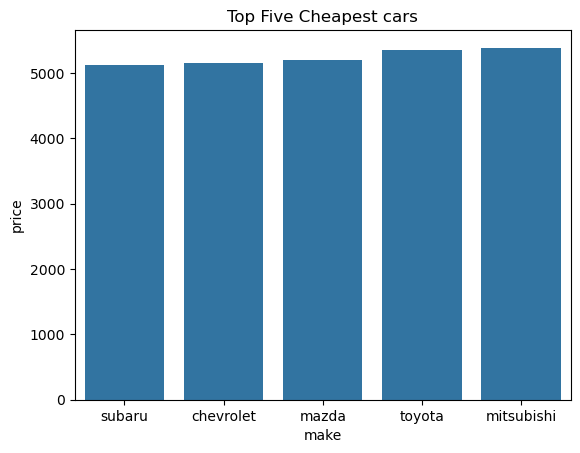

In [30]:
sns.barplot(data=top_five_cheapest, x='make', y='price')
plt.title('Top Five Cheapest cars')
plt.show()

In [31]:
comarison_df = pd.concat([top_five_expensive.assign(Category='Expensive'),
                          top_five_cheapest.assign(Category='Cheapest')
                         ])
print(comarison_df[['make','price','length','width','height','curb-weight','engine-size','compression-ratio','city-mpg', 'highway-mpg']])

              make  price  length  width  height  curb-weight  engine-size  \
74   mercedes-benz  45400     199     72      55         3715          304   
16             bmw  41315     193     67      53         3380          209   
73   mercedes-benz  40960     208     71      56         3900          308   
128        porsche  37028     168     65      51         2800          194   
17             bmw  36880     197     70      56         3505          209   
138         subaru   5118     156     63      53         2050           97   
18       chevrolet   5151     141     60      53         1488           61   
50           mazda   5195     159     64      54         1890           91   
150         toyota   5348     158     63      54         1985           92   
76      mitsubishi   5389     157     64      50         1918           92   

     compression-ratio  city-mpg  highway-mpg  
74                   8        14           16  
16                   8        16           22

Text(0.5, 1.02, 'price distrution by make, category')

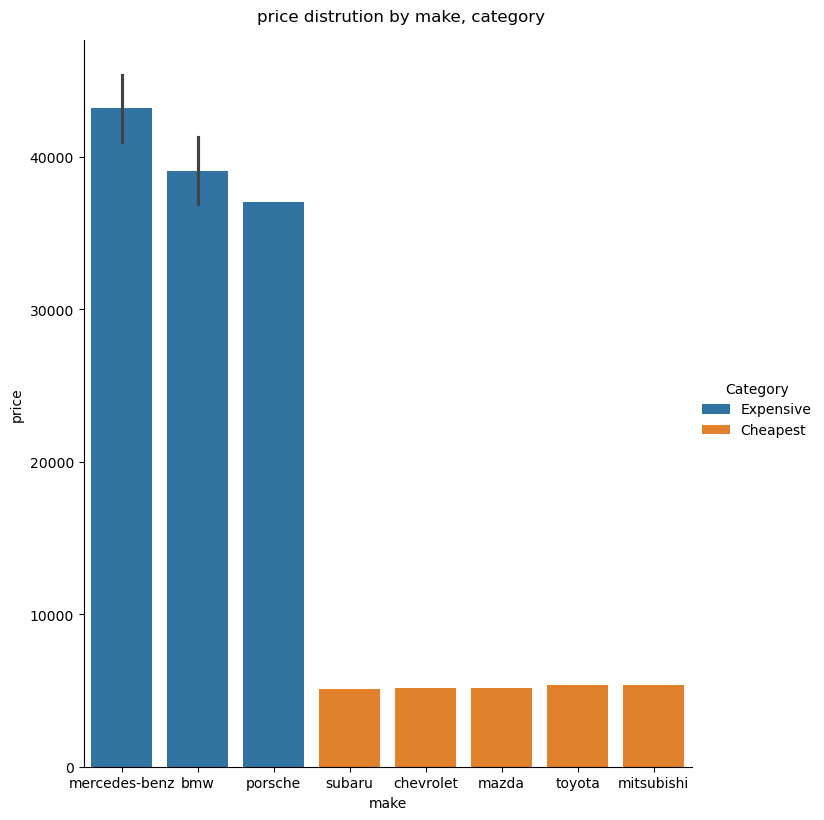

In [32]:
g= sns.catplot(x='make', y='price', hue='Category' , data=comarison_df, kind='bar',  height=8, aspect=0.9)
g.fig.suptitle('price distrution by make, category', y=1.02)

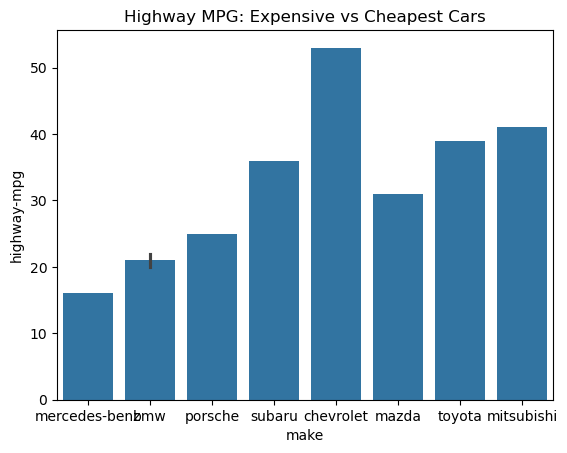

In [33]:
sns.barplot(data=comarison_df, x='make', y='highway-mpg')
plt.title('Highway MPG: Expensive vs Cheapest Cars')
plt.show()

# Bar Plot

Text(0.5, 1.02, 'highway-mpg, city-mpg by category')

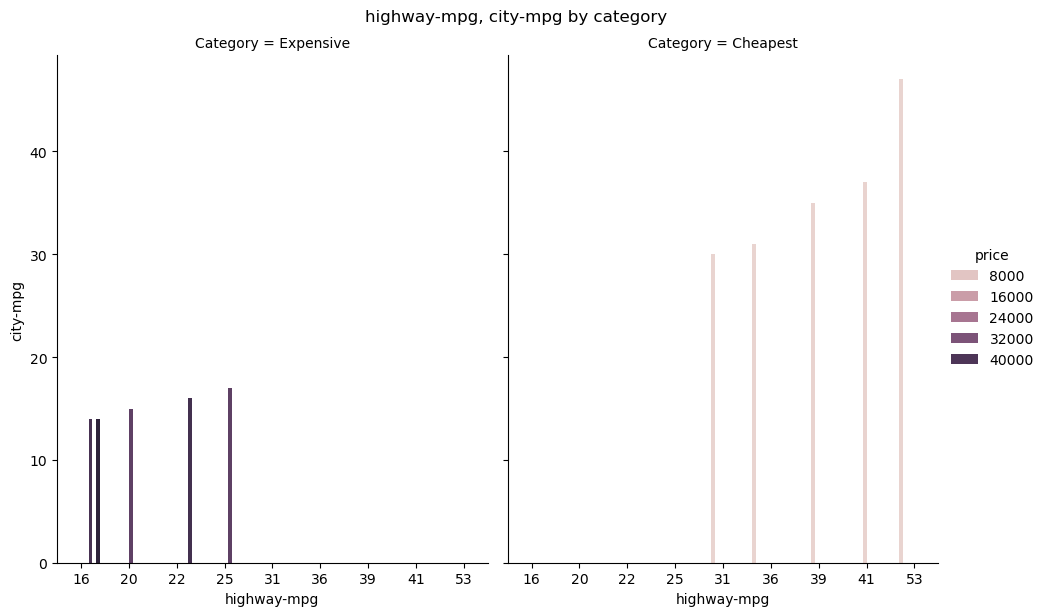

In [34]:
g= sns.catplot(x='highway-mpg', y='city-mpg', hue='price', col='Category'  , data=comarison_df,  kind='bar',  height=6, aspect=0.8)
g.fig.suptitle('highway-mpg, city-mpg by category', y=1.02)

# scatter Plot - Highway MPG vs Category (Cheapest and Expensive)

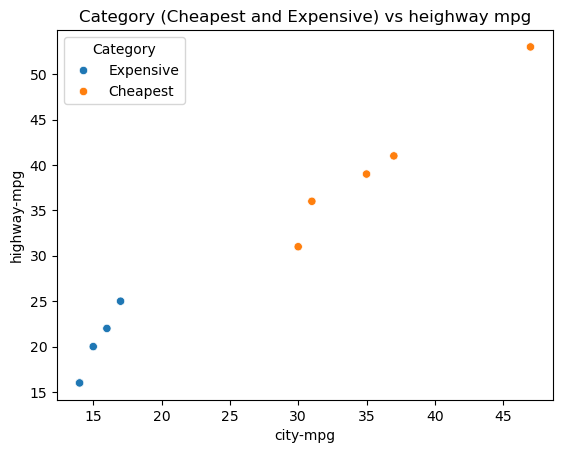

In [35]:
sns.scatterplot(data=comarison_df, y="highway-mpg", hue='Category', x='city-mpg')
plt.title('Category (Cheapest and Expensive) vs heighway mpg')
plt.show()

# Strip plot for highway-mpg , city-mpg and price disdtribution by Category

Text(0.5, 1.05, 'highway-mpg,city-mpg and price disdtribution by Category')

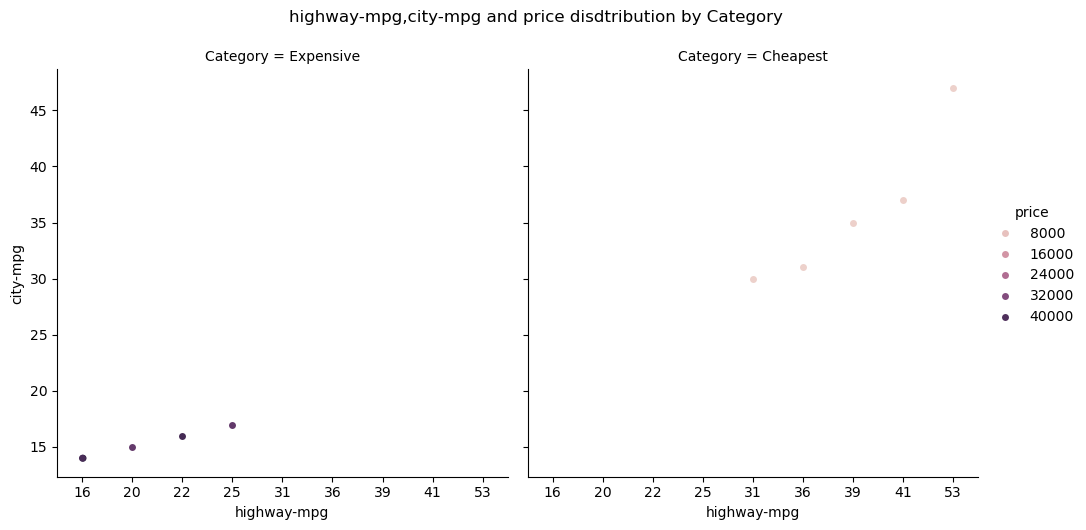

In [36]:
g= sns.catplot(x='highway-mpg', y='city-mpg', hue='price', col='Category' , data=comarison_df, kind='strip',   height=5, aspect=1)
g.fig.suptitle('highway-mpg,city-mpg and price disdtribution by Category', y=1.05)

# Heatmap - correlations between Variables

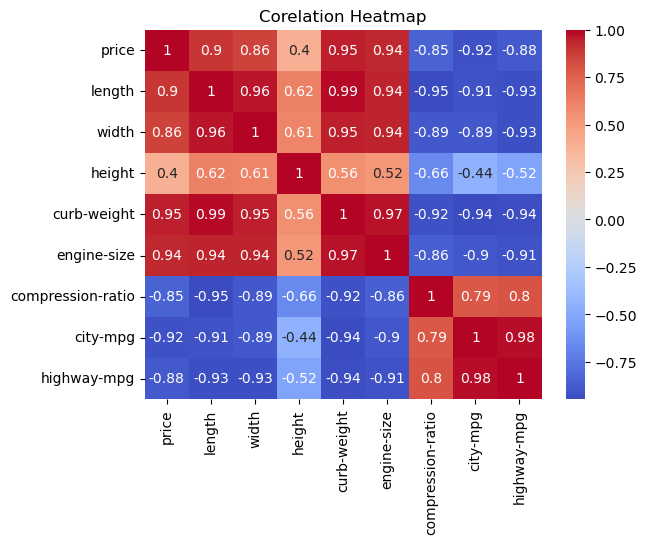

In [37]:
sns.heatmap(comarison_df[['price','length','width','height','curb-weight','engine-size','compression-ratio','city-mpg', 'highway-mpg']].corr(), annot=True, cmap='coolwarm')
plt.title('Corelation Heatmap')
plt.show()

# Pair Plot - compare multiple variables

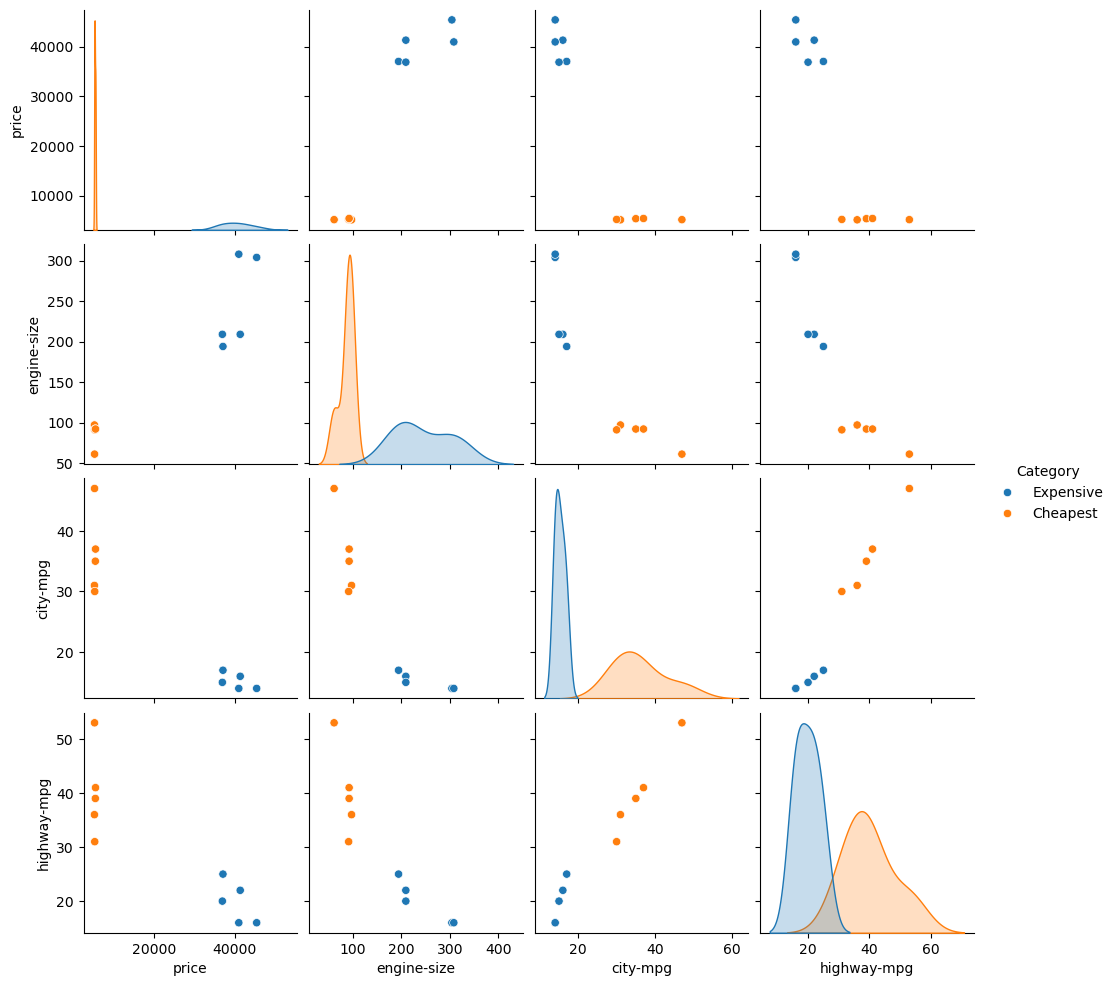

In [38]:
sns.pairplot(comarison_df, vars=['price','engine-size','city-mpg', 'highway-mpg'], hue="Category")
plt.show()

#### Which manufacturer builds the most fuel efficient vehicles?

Compare the average mpg for each vehicle manufacture's vehicles and create a bar plot

In [39]:
# Code here
avg_city_mpg = automobiles_df.groupby('make')['city-mpg'].mean().sort_values(ascending=False)
avg_highway_mpg = automobiles_df.groupby('make')['highway-mpg'].mean().sort_values(ascending=False)


In [ ]:
print(avg_city_mpg)

In [ ]:
print(avg_highway_mpg)

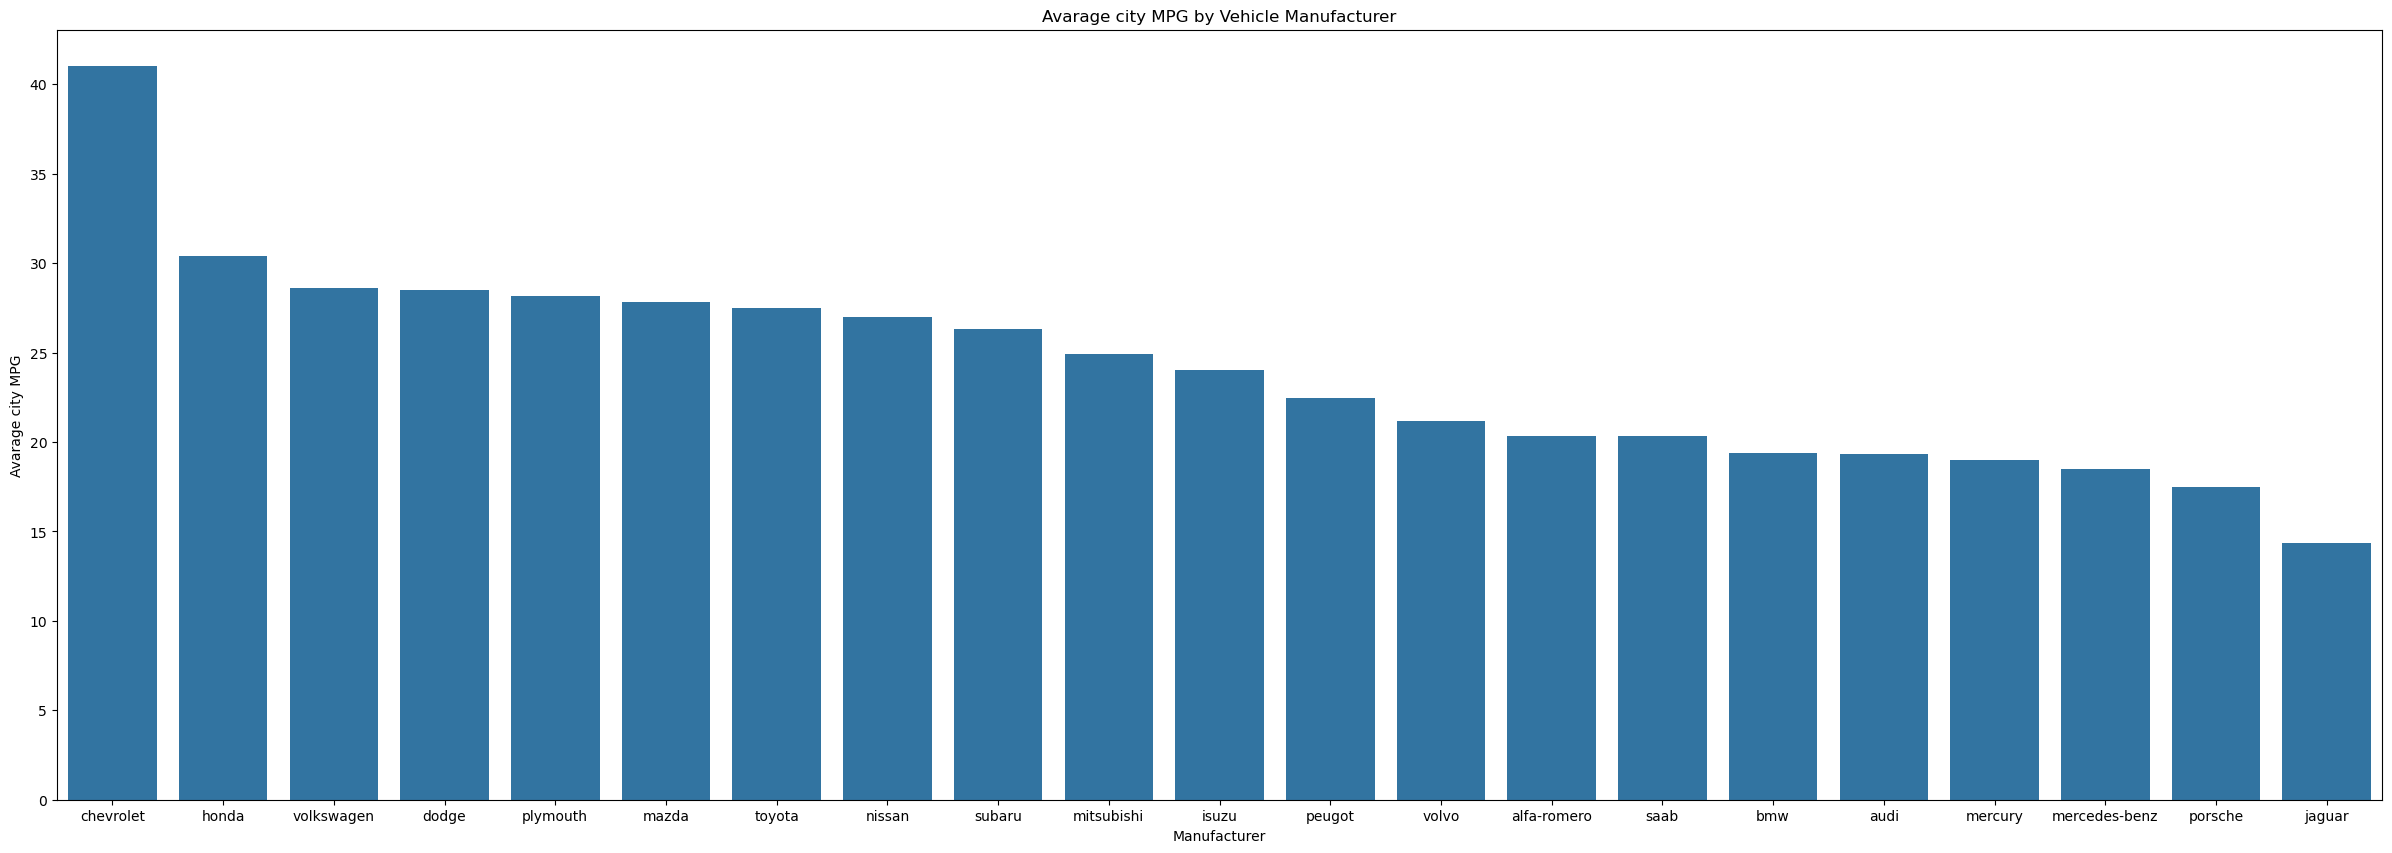

In [40]:
avg_city_mpg_df = avg_city_mpg.reset_index()
plt.figure(figsize=(30,10))
sns.barplot(data=avg_city_mpg_df , x='make', y='city-mpg' )
plt.title('Avarage city MPG by Vehicle Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Avarage city MPG')
plt.show()

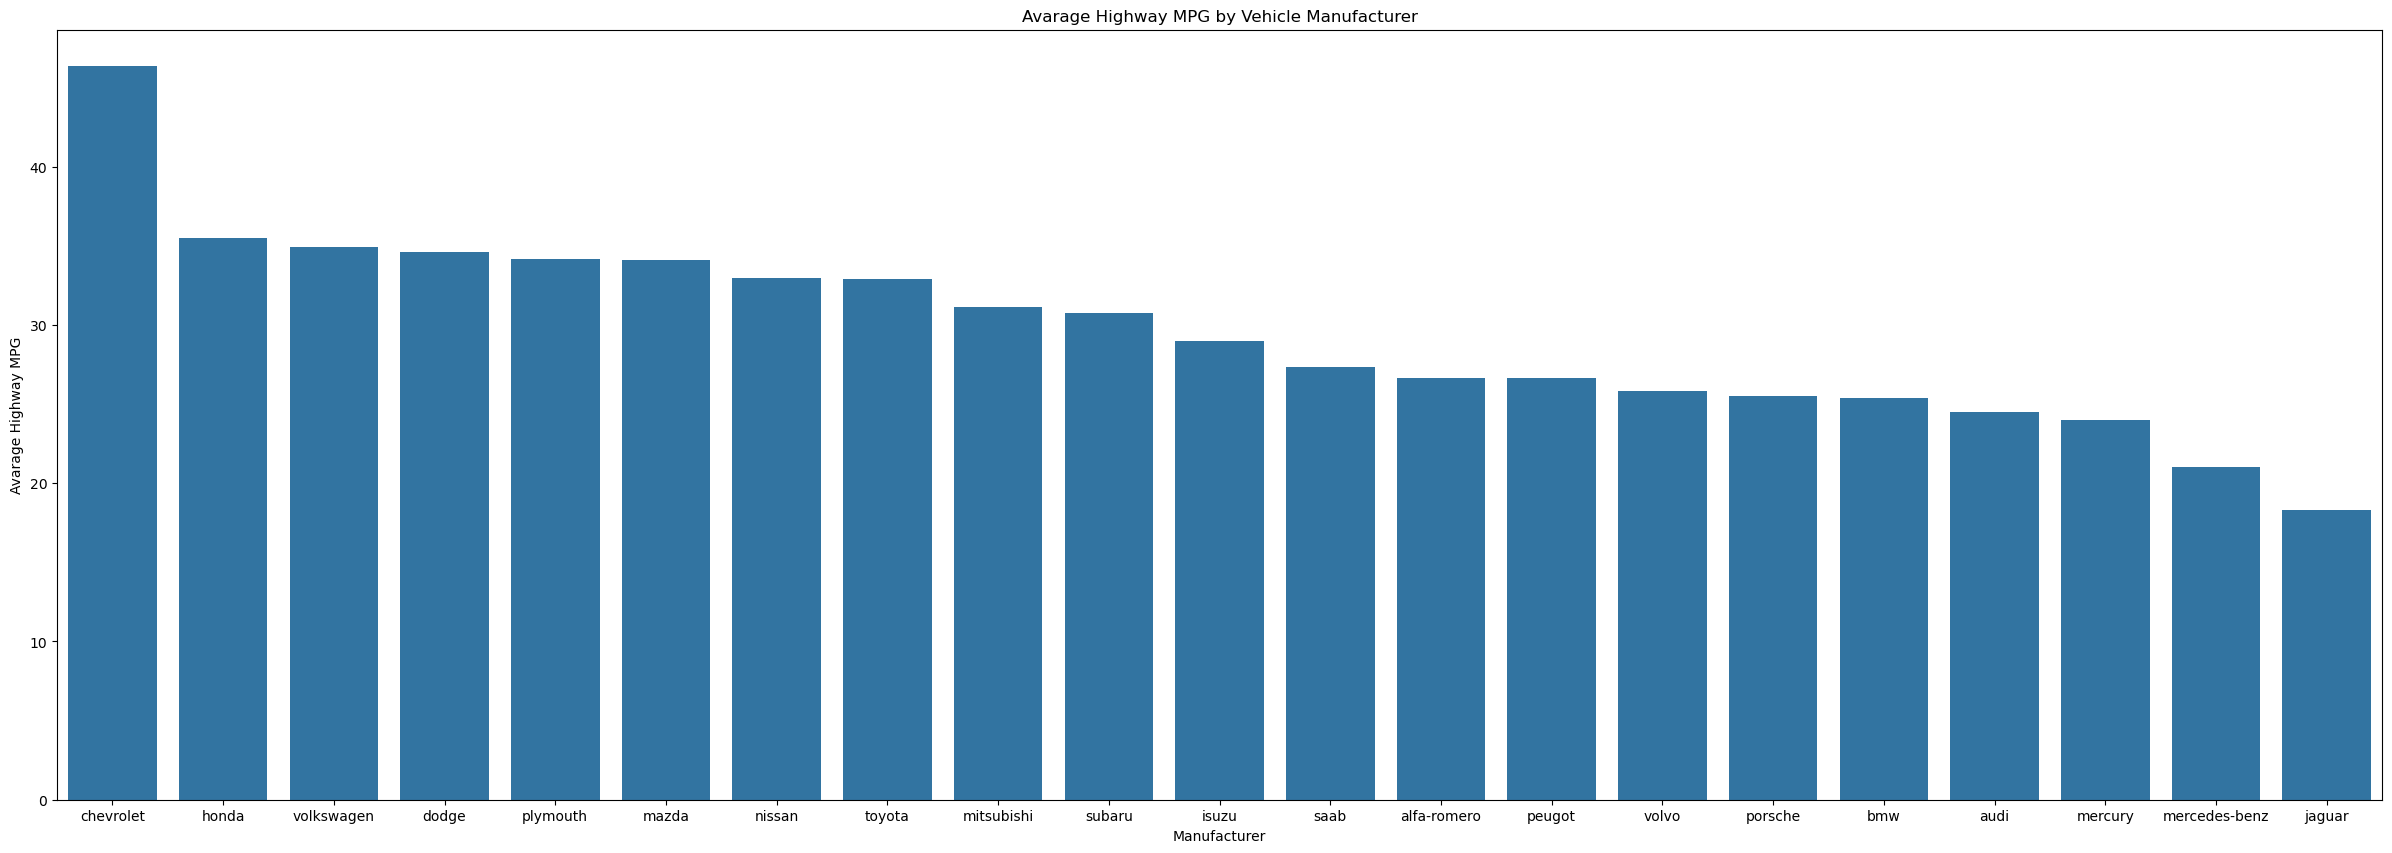

In [41]:
avg_highway_mpg_df = avg_highway_mpg.reset_index()
plt.figure(figsize=(30,10))
sns.barplot(data=avg_highway_mpg_df , x='make', y='highway-mpg' )
plt.title('Avarage Highway MPG by Vehicle Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Avarage Highway MPG')
plt.show()

#### Which vehicles have the largest engine capacity.
Sort the dataframe based on the engine-size column.

In [42]:
# Code here
largest_engine_size = automobiles_df.sort_values(by='engine-size', ascending=False)
print(largest_engine_size[['make','engine-size']])


              make  engine-size
49          jaguar          326
73   mercedes-benz          308
74   mercedes-benz          304
47          jaguar          258
48          jaguar          258
..             ...          ...
25           dodge           90
121       plymouth           90
118       plymouth           90
32           honda           79
18       chevrolet           61

[193 rows x 2 columns]


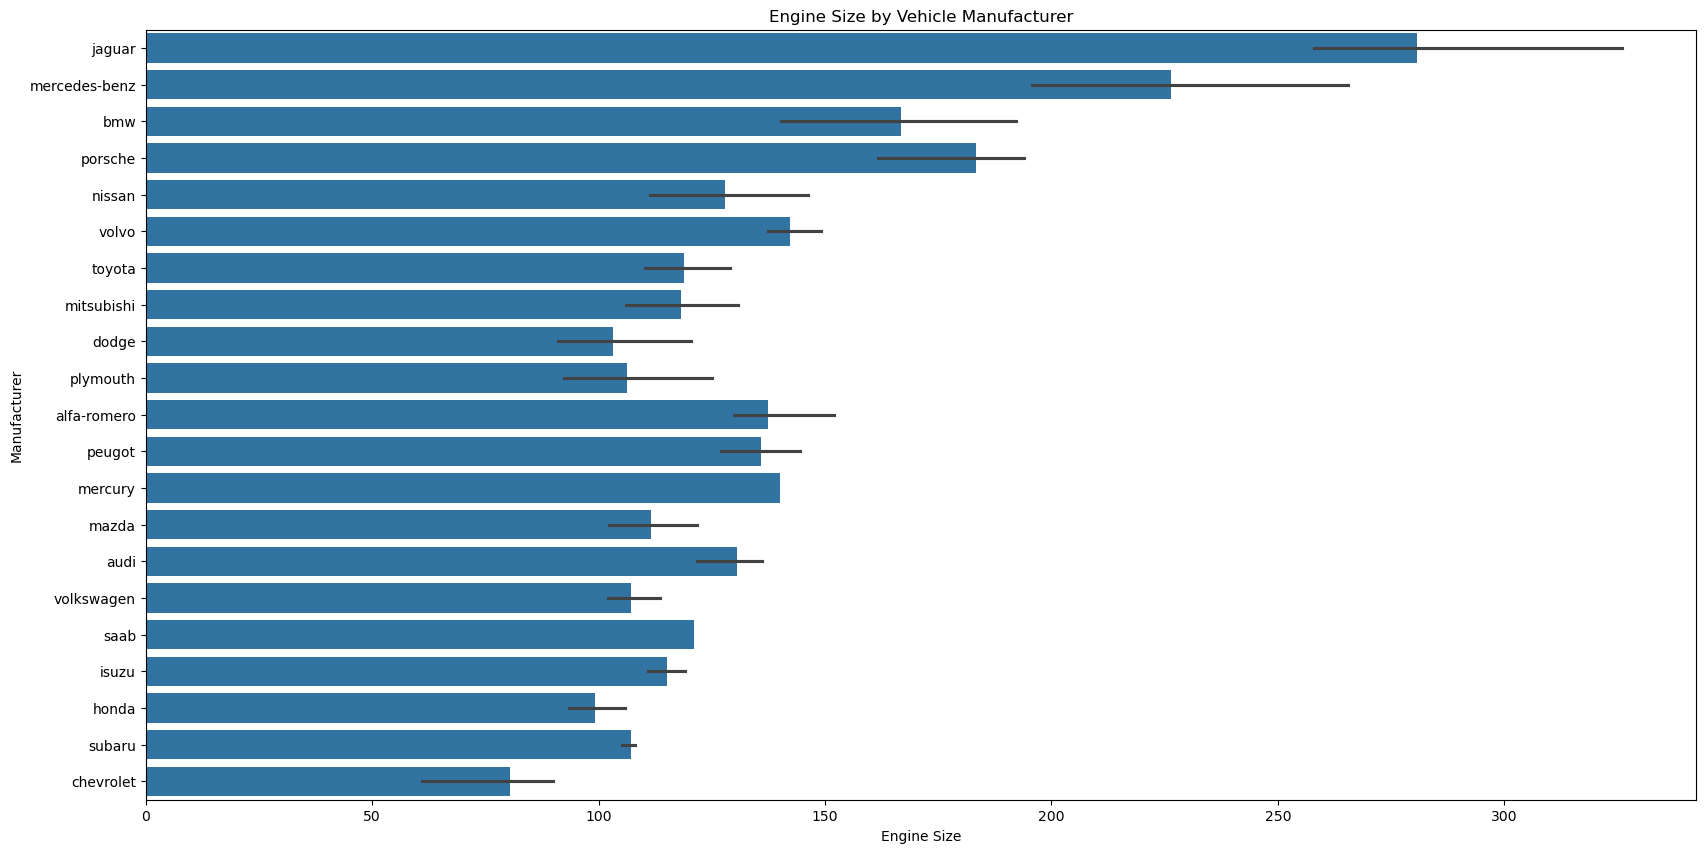

In [43]:
plt.figure(figsize=(20,10))
sns.barplot(data=largest_engine_size , x='engine-size', y='make' )
plt.title('Engine Size by Vehicle Manufacturer')
plt.xlabel('Engine Size')
plt.ylabel('Manufacturer')
plt.show()

#### Which vehicle manufacturer has the most car models in the dataset

In [44]:
# Code here

maufacturer_count = automobiles_df['make'].value_counts()
print(maufacturer_count)


make
toyota           32
nissan           18
honda            13
mitsubishi       13
mazda            12
subaru           12
volkswagen       12
peugot           11
volvo            11
bmw               8
dodge             8
mercedes-benz     8
plymouth          7
audi              6
saab              6
porsche           4
alfa-romero       3
chevrolet         3
jaguar            3
isuzu             2
mercury           1
Name: count, dtype: int64


In [45]:
print(maufacturer_count.idxmax())
print(maufacturer_count.max())

toyota
32


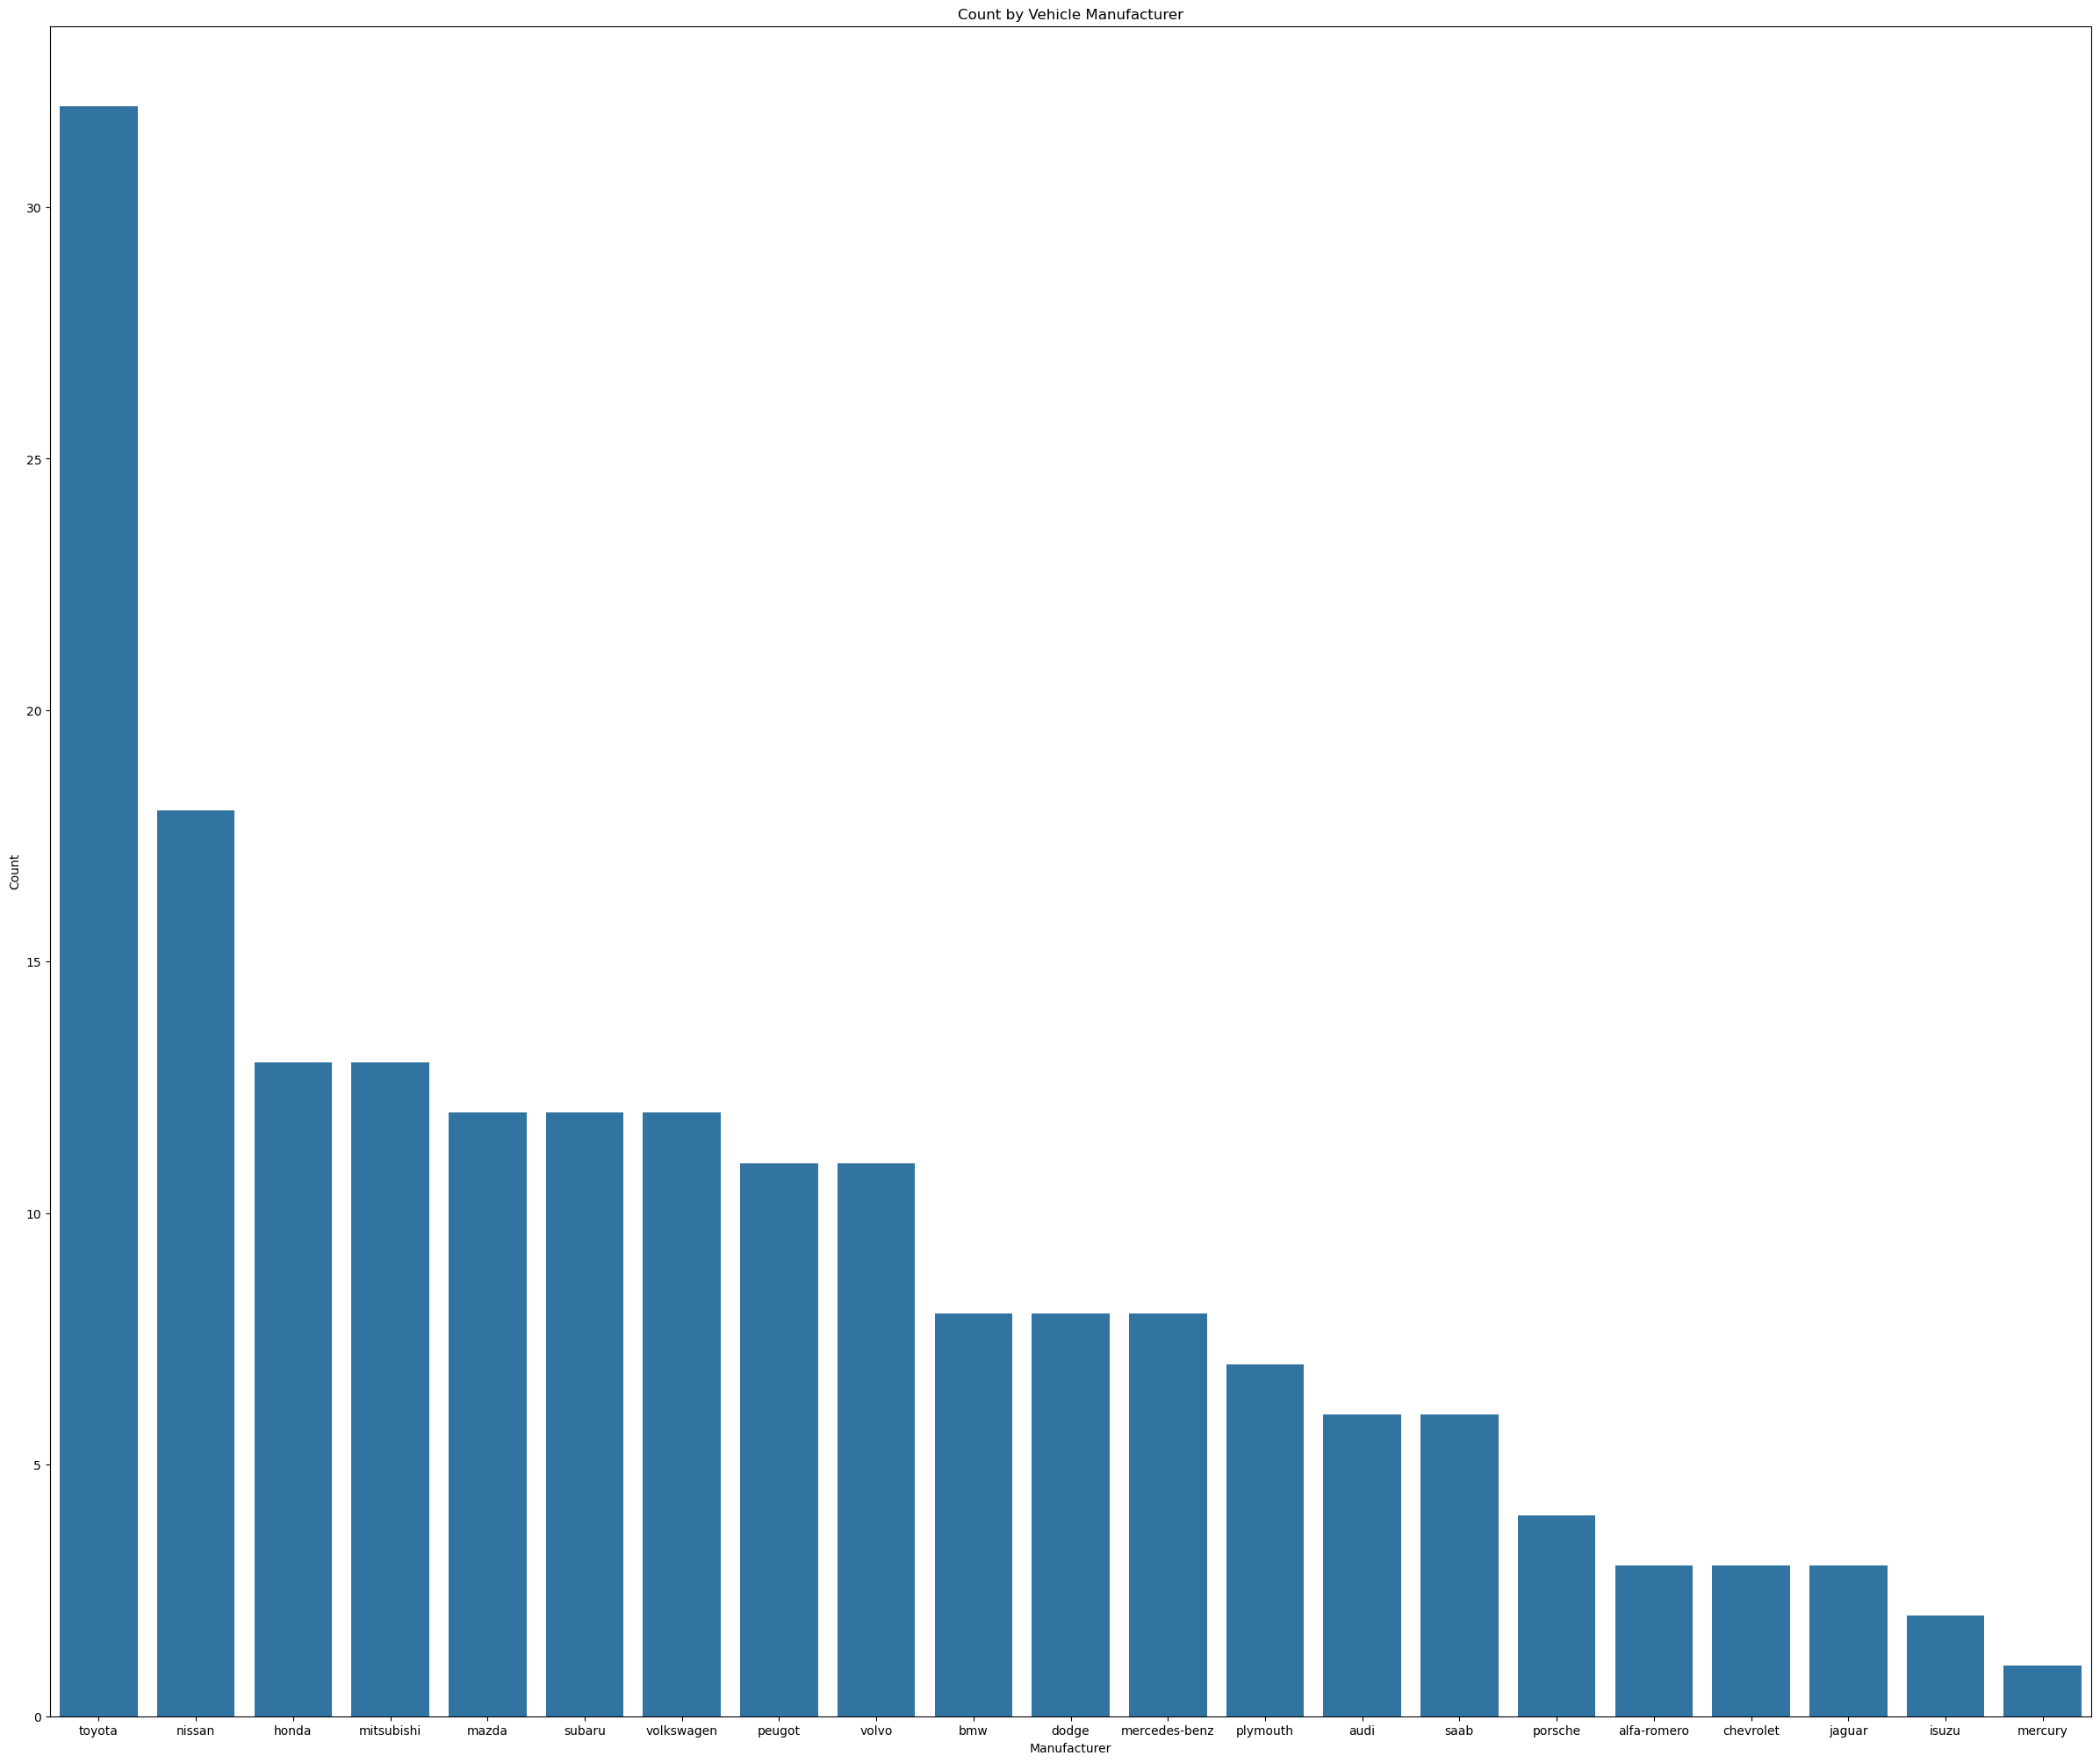

In [46]:
maufacturer_count_df = maufacturer_count.reset_index()
maufacturer_count_df.columns = ['make','count']

plt.figure(figsize=(30,25))
sns.barplot(data=maufacturer_count_df , x='make', y='count' )
plt.title('Count by Vehicle Manufacturer')
plt.xlabel('Manufacturer')
plt.ylabel('Count')
plt.show()

#Visualisations

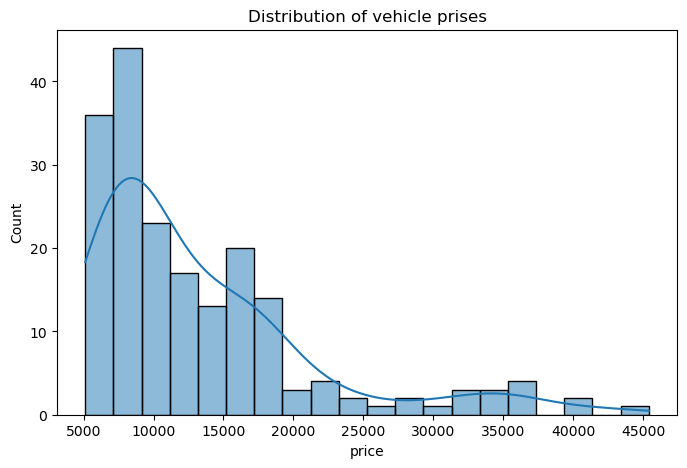

In [47]:
# Distribution of vehicle prises
plt.figure(figsize=(8,5))
sns.histplot(automobiles_df["price"], bins=20, kde=True)
plt.title("Distribution of vehicle prises")
plt.show()

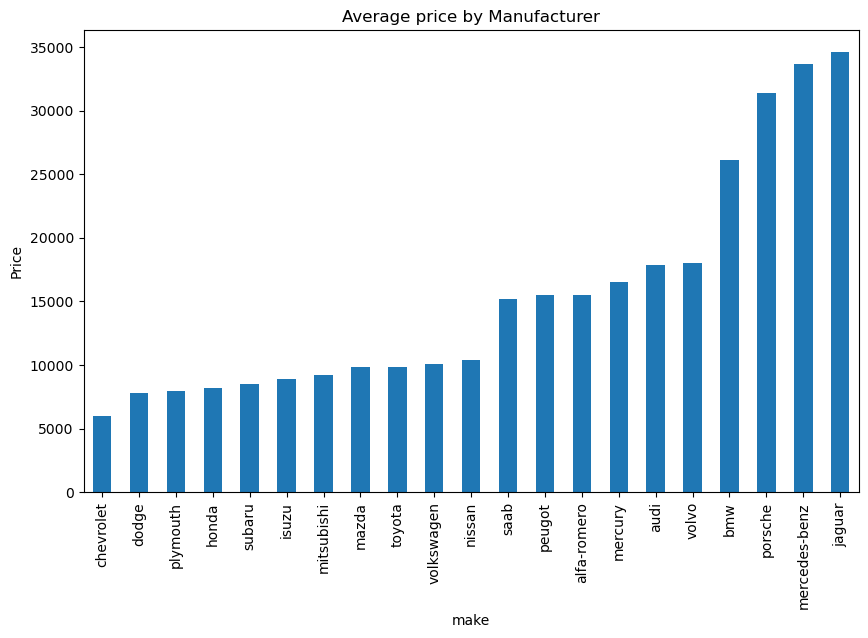

In [48]:
# AVerage Prise by make
avg_price = automobiles_df.groupby('make') ['price'].mean().sort_values()

plt.figure(figsize=(10,6))
avg_price.plot(kind='bar')
plt.title('Average price by Manufacturer')
plt.ylabel('Price')
plt.show()

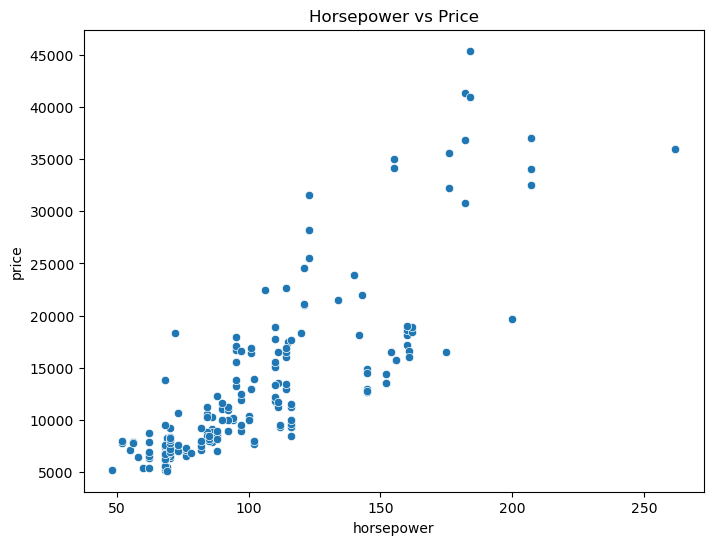

In [49]:
#Hoursepower vs Price

plt.figure(figsize=(8,6))
sns.scatterplot(data=automobiles_df, x='horsepower', y="price")
plt.title('Horsepower vs Price')
plt.show()

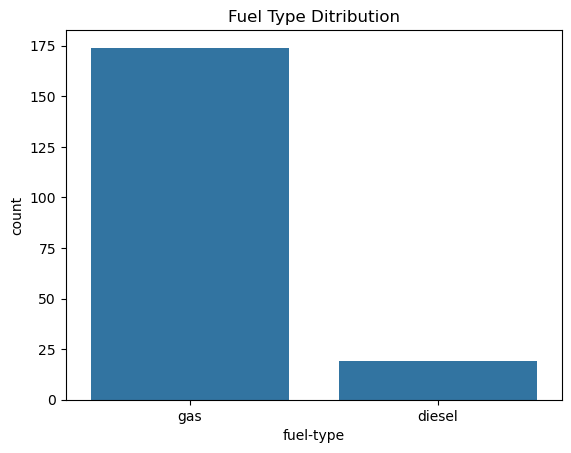

In [50]:
# Fuel Type Distribution

sns.countplot(data= automobiles_df, x='fuel-type')
plt.title("Fuel Type Ditribution")
plt.show()

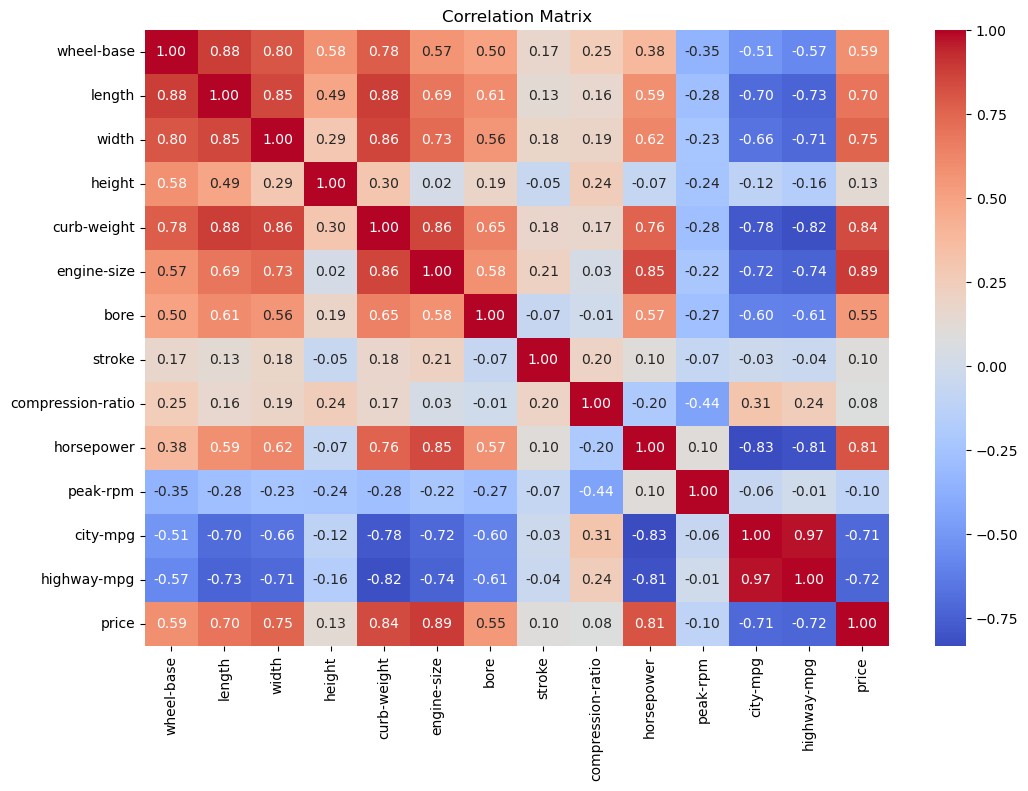

In [51]:
# Correlation Heatmap

plt.figure(figsize=(12,8))

numeric_df = automobiles_df.select_dtypes(include=["int64","float64"])

sns.heatmap(
    numeric_df.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Correlation Matrix')
plt.show()